In [1]:
import numpy as np
import networkx as nx

from itertools import combinations
from qiskit import QuantumCircuit, transpile
from qiskit.circuit.library import PauliEvolutionGate, CXGate, QAOAAnsatz

from qiskit_aer import AerSimulator
from qiskit_aer.backends.backendconfiguration import AerBackendConfiguration

from qopt_best_practices.sat_mapping import SATMapper
from qiskit_qaoa.utils.sat_mapper import HigherOrderSatMapper

from qiskit.quantum_info import SparsePauliOp


from qiskit.transpiler import PassManager
from qiskit.transpiler.passes import HighLevelSynthesis, InverseCancellation
from qopt_best_practices.transpilation.swap_cancellation_pass import SwapToFinalMapping


from qiskit_qaoa.utils.transpiler_passes import ExtendedSwapStrategy, FindCommutingPauliEvolutionsMulti, DecomposePauliZEvolution

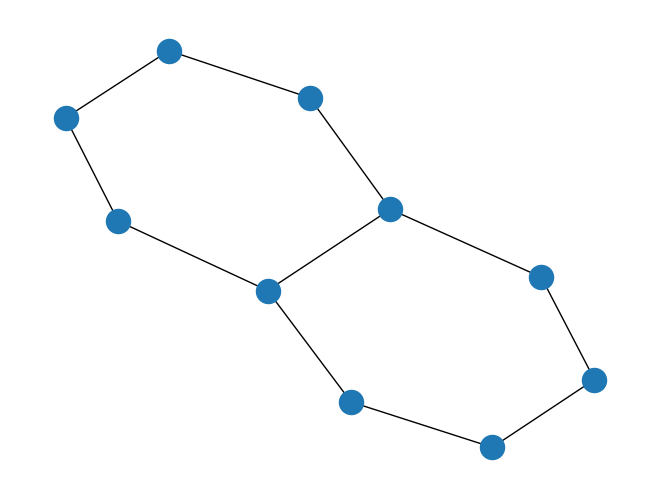

In [5]:
nx.draw(nx.hexagonal_lattice_graph(2,1))

In [6]:
extended_swap_strat = ExtendedSwapStrategy.from_heavy_hex(2, 1)
num_physical_qubits = extended_swap_strat._num_vertices
num_physical_qubits

{(0, 0): 0, (0, 1): 1, (0, 2): 2, (1, 0): 3, (1, 1): 4, (1, 2): 5, (1, 3): 6, (2, 1): 7, (2, 2): 8, (2, 3): 9, ((0, 0), (0, 1)): 10, ((0, 1), (0, 0)): 10, ((0, 0), (1, 0)): 11, ((1, 0), (0, 0)): 11, ((0, 1), (0, 2)): 12, ((0, 2), (0, 1)): 12, ((0, 2), (1, 2)): 13, ((1, 2), (0, 2)): 13, ((1, 0), (1, 1)): 14, ((1, 1), (1, 0)): 14, ((1, 1), (1, 2)): 15, ((1, 2), (1, 1)): 15, ((1, 1), (2, 1)): 16, ((2, 1), (1, 1)): 16, ((1, 2), (1, 3)): 17, ((1, 3), (1, 2)): 17, ((1, 3), (2, 3)): 18, ((2, 3), (1, 3)): 18, ((2, 1), (2, 2)): 19, ((2, 2), (2, 1)): 19, ((2, 2), (2, 3)): 20, ((2, 3), (2, 2)): 20}
((13, 2), (12, 1), (10, 0), (11, 3), (14, 4), (15, 5), (17, 6), (18, 9), (20, 8), (19, 7))
((2, 12), (1, 10), (0, 11), (3, 14), (4, 15), (5, 17), (6, 18), (9, 20), (8, 19))
((16, 4),)
()


21

In [3]:
extended_swap_strat.distance_tensor(3)[0,2,:]

14:09:21 - qiskit_qaoa.utils.swap_strategy - INFO - Computing data


array([ -1,  27,  -1,  -1, 120,  27,  -1,  29,  -1,  -1,  46,  -1,  -1,
        -1,  -1,  48,  33, 117,  -1,  -1,  18,  17,  -1,  -1,  18,  -1,
        -1,  -1,  -1,  -1,  -1,  90,  -1,  -1,  71])

W = 3
array([ -1,  27,  -1,  -1, 120,  27,  -1,  29,  -1,  -1,  46,  -1,  -1,
        -1,  -1,  48,  33, 117,  -1,  -1,  18,  17,  -1,  -1,  18,  -1,
        -1,  -1,  -1,  -1,  -1,  90,  -1,  -1,  71])

        13


W = 1
array([-1,  7, -1,  7, -1,  8, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1, 44, -1, -1, -1, -1, -1, 78, -1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1])

       5

In [ ]:
extended_swap_strat._swap_layers[1]

In [ ]:
coupling_map_edge = list(extended_swap_strat._coupling_map)
physical_qubits = list(extended_swap_strat._coupling_map.physical_qubits)
dual_coupling_map = nx.Graph()

for qubit in physical_qubits:
    edges = [edge for edge in coupling_map_edge if edge[0]==qubit]
    for edge1, edge2 in combinations(edges, 2):
        dual_coupling_map.add_edge(tuple(sorted(edge1)), tuple(sorted(edge2)))



In [ ]:
pos = nx.spring_layout(dual_coupling_map)
nx.draw(dual_coupling_map, pos=pos, with_labels=True)

In [ ]:
# colour = nx.equitable_color(dual_coupling_map, 3)
colour = nx.greedy_color(dual_coupling_map, interchange=True)

colours = ['red', 'blue', 'green', 'black']
nx.draw(dual_coupling_map, pos=pos, with_labels=True)
for val in colour.values():
    nx.draw_networkx_nodes(dual_coupling_map, pos, nodelist=[x for x in colour.keys() if colour[x] == val], node_color=colours[val])


In [ ]:
n = 3
T = 3
num_qubits = n*T

In [ ]:
rng = np.random.default_rng(seed=1)
doubles = rng.choice(num_qubits, (20, 2))
quads = rng.choice(num_qubits, (2, 4), replace=False)
coeffs = rng.random(22)

In [ ]:
def choice_to_pauli(choice: list[int], size: int) -> str:
    pauli = ['I'] * size
    for x in choice:
        pauli[size - x - 1] = 'Z'
    return ''.join(pauli)

In [ ]:
hamiltonian = SparsePauliOp([choice_to_pauli(c, num_qubits) for c in doubles] + [choice_to_pauli(c, num_qubits) for c in quads], coeffs=coeffs)
hamiltonian = hamiltonian.simplify()
hamiltonian = hamiltonian.sort(weight=True)


In [ ]:
def hamiltonian_to_doubles_graph(hamiltonian: SparsePauliOp) -> nx.Graph:
    edges = []
    weights = []
    for t in hamiltonian:
        if np.sum(t.paulis[0].z) == 2:
            edge = np.nonzero(t.paulis[0].z)[0]
            edges.append(edge)
            weights.append(t.coeffs[0])
            
    program_graph = nx.Graph()
    for i in range(hamiltonian.num_qubits):
        program_graph.add_node(i)
    for idx in range(len(weights)):
        program_graph.add_edge(edges[idx][0],edges[idx][1],weight=weights[idx])
    return program_graph


In [ ]:
def hamiltonian_to_interactions(hamiltonian: SparsePauliOp) -> list[tuple]:
    interactions = []
    for t in hamiltonian:
        if np.sum(t.paulis[0].z) < 1 or np.sum(t.paulis[0].z) > 5:
            continue
        if np.sum(t.paulis[0].z) == 2:
            edge = np.nonzero(t.paulis[0].z)[0]
            interactions.append(edge)
        if np.sum(t.paulis[0].z) == 4:
            edge = np.nonzero(t.paulis[0].z)[0]
            interactions.append(edge)
    return interactions

In [ ]:
def print_circuit_info(qc, circuit_name):
    print(f'{circuit_name} has {qc.count_ops().get("cz", 0) + qc.count_ops().get("rzz", 0) + qc.count_ops().get("cx", 0)} 2Q gates \
    and {qc.depth(lambda instr: len(instr.qubits) > 1)} 2Q depth')

In [ ]:
basis_gates=["sx", "x", "rz", "rzz", "cz", "id"]
config = AerSimulator._DEFAULT_CONFIGURATION
config["n_qubits"] = num_physical_qubits
config["basis_gates"] = basis_gates
config = AerBackendConfiguration.from_dict(config)
backend = AerSimulator(configuration=config, coupling_map=extended_swap_strat._coupling_map)

In [ ]:
backend._basis_gates()

In [ ]:
pm = PassManager(
    [
        HighLevelSynthesis(basis_gates=["PauliEvolution"]), # Not needed if set up circuit as PauliEvolutionGate
        FindCommutingPauliEvolutionsMulti(), 
        CommutingGateRouter(
            extended_swap_strat,
        ),
        SwapToFinalMapping(),
        HighLevelSynthesis(basis_gates=["sx", "x", "rz", "rzz", "cx", "id"]),
        InverseCancellation(gates_to_cancel=[CXGate()]),
    ]
)

In [ ]:
program_graph = hamiltonian_to_doubles_graph(hamiltonian)


In [ ]:
sat_results = SATMapper(timeout=60).find_initial_mappings(
    program_graph, extended_swap_strat, 0, len(extended_swap_strat)
)
solutions = [k for k, v in sat_results.items() if v.satisfiable]


In [ ]:
solutions

In [ ]:
if len(solutions):
    min_k = min(solutions)
    print(f'Min SWAP layers to satisfy doubles: {min_k}')
    edge_map = dict(sat_results[min_k].mapping)
    print(f'Doubles edge map: {edge_map}')

    new_hamiltonian = hamiltonian.apply_layout([edge_map[i] for i in range(num_qubits)], num_physical_qubits)
    
    new_cost_circ = QuantumCircuit(num_physical_qubits)
    new_cost_circ.append(PauliEvolutionGate(new_hamiltonian), range(num_physical_qubits))
    new_tcost = pm.run(new_cost_circ)
    
    print_circuit_info(new_tcost, 'Remapped, commuting gate routed circuit')
    print(new_tcost.count_ops())
    
    backend_new_tcost = transpile(new_tcost, optimization_level=3, backend=backend, basis_gates=basis_gates)
    
    print_circuit_info(backend_new_tcost, 'Remapped, commuting gate routed circuit on backend')
    print(backend_new_tcost.count_ops())

In [ ]:
qaoa_cost_op = QAOAAnsatz(
    hamiltonian,
    mixer_operator=QuantumCircuit(num_qubits),
    initial_state=QuantumCircuit(num_qubits)
)
backend_tqaoa = transpile(qaoa_cost_op, optimization_level=3, backend=backend, basis_gates=basis_gates)

print_circuit_info(backend_tqaoa, 'Default qaoa circuit on backend')
print(backend_tqaoa.count_ops())

In [ ]:
program_interactions = hamiltonian_to_interactions(hamiltonian)
nodes = set([node for interaction in program_interactions for node in interaction])

In [ ]:
mapper = HigherOrderSatMapper(timeout=5)
results = {}
for num_layers in range(2,3):
    print('--------------------------------------------------')
    sat_results = mapper.hubo_max_sat(
        program_interactions, extended_swap_strat, num_layers
    )
    mapping = sat_results[num_layers][1]
    edge_map = dict(mapping)
    print(f'Cost: {sat_results[num_layers][0]}')
    print(edge_map)

Why cost 2 but can't do 7 gates?? Error in SAT mapping?

In [ ]:
edge_map = {0: 9, 1: 24, 2: 20, 3: 1, 4: 7, 5: 23, 6: 28, 7: 26, 8: 8}
num_layers = 2
results = {}

In [ ]:
print(program_interactions[-2:])

print(quads)
[[edge_map[q] for q in quad] for quad in quads]

In [ ]:
new_hamiltonian = hamiltonian.apply_layout([edge_map[i] for i in range(num_qubits)], num_physical_qubits)
print([np.nonzero(p.paulis.z)[1] for p in hamiltonian[-2:]])
print([np.nonzero(p.paulis.z)[1] for p in new_hamiltonian[-2:]])

In [ ]:
pm = PassManager(
    [
        # HighLevelSynthesis(basis_gates=["PauliEvolution"]), # Not needed if set up circuit as PauliEvolutionGate
        FindCommutingPauliEvolutionsMulti(), 
        CommutingGateRouter(
            extended_swap_strat,
            max_layers=num_layers,
            perform_extra_swaps=False
        ),
        SwapToFinalMapping(),
        DecomposePauliZEvolution(extended_swap_strat._coupling_map),
        HighLevelSynthesis(
            basis_gates=["sx", "x", "rz", "rzz", "cx", "id", "swap"], 
        ),
        InverseCancellation(gates_to_cancel=[CXGate()]),
    ]
)

In [ ]:
new_cost_circ = QuantumCircuit(num_physical_qubits)
new_cost_circ.append(PauliEvolutionGate(new_hamiltonian), range(num_physical_qubits))
new_tcost = pm.run(new_cost_circ)

print_circuit_info(new_tcost, 'Remapped, commuting gate routed circuit')
print(new_tcost.count_ops())

backend_new_tcost = transpile(new_tcost, optimization_level=3, backend=backend, basis_gates=basis_gates)

print_circuit_info(backend_new_tcost, 'Remapped, commuting gate routed circuit on backend')
print(backend_new_tcost.count_ops())
results[num_layers] = (new_tcost, backend_new_tcost)
    

In [ ]:
[x for x in list(backend.coupling_map) if x[0] == 8] + [x for x in list(backend.coupling_map) if x[0] == 13]

In [ ]:
[x for x in list(backend.coupling_map) if x[0] == 9] + [x for x in list(backend.coupling_map) if x[0] == 22]

In [ ]:
results[2][0].draw(fold=-1)

In [ ]:
results[4][1].draw(fold=-1)

In [ ]:
sat_results = HigherOrderSatMapper(timeout=5).find_hubo_mappings(
    program_interactions, extended_swap_strat, 0, len(extended_swap_strat)
)
solutions = [k for k, v in sat_results.items() if v.satisfiable]

In [ ]:
solutions

In [ ]:
if len(solutions):
    min_k = min(solutions)
    print(f'Min SWAP layers to satisfy HUBO: {min_k}')
    edge_map = dict(sat_results[min_k].mapping)
    print(f'Doubles edge map: {edge_map}')

    new_hamiltonian = hamiltonian.apply_layout([edge_map[i] for i in range(num_qubits)], num_physical_qubits)
    
    new_cost_circ = QuantumCircuit(num_physical_qubits)
    new_cost_circ.append(PauliEvolutionGate(new_hamiltonian), range(num_physical_qubits))
    new_tcost = pm.run(new_cost_circ)
    
    print_circuit_info(new_tcost, 'Remapped, commuting gate routed circuit')
    print(new_tcost.count_ops())
    
    backend_new_tcost = transpile(new_tcost, optimization_level=3, backend=backend, basis_gates=basis_gates)
    
    print_circuit_info(backend_new_tcost, 'Remapped, commuting gate routed circuit on backend')
    print(backend_new_tcost.count_ops())

In [ ]:
new_tcost.draw(fold=-1)

In [ ]:
backend_tqaoa.draw(fold=-1)

In [ ]:
len(extended_swap_strat)